In [ ]:
# Ячейка 1: Установка библиотек (исправленная версия)
# Эта команда установит torch_geometric и все его зависимости (включая pyg-lib)
# из официального репозитория PyG, автоматически подбирая версии под ваш PyTorch.

%pip install torch_geometric pyg_lib -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [2]:
# --- Импорты ---
import pandas as pd
import numpy as np
import re
import os
import torch
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.nn import SAGEConv, GATv2Conv 
from torch.nn import Linear, ReLU, Dropout, Sequential, BatchNorm1d 

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

print("Все библиотеки успешно импортированы.")

Все библиотеки успешно импортированы.


In [3]:
# --- Временные признаки и сохранение индексов ---
import pandas as pd
import numpy as np
import re
import os
import pickle
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import torch
from torch_geometric.data import Data

# 1. Загрузка и базовая обработка
print("1. Загрузка и базовая обработка...")
KAGGLE_DATASET_PATH = "/kaggle/input/df-baseline/df_baseline.csv"
df = pd.read_csv(KAGGLE_DATASET_PATH, sep=',')
df.columns = df.columns.str.strip().str.lower()
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df = df.sort_values('datetime').reset_index(drop=True)
df = df.drop(columns=['year', 'date', 'time'])

# 2. Создание признаков ребер (Edge Features)
print("\n2. Создание признаков для транзакций (ребер)...")
def get_pattern_type(laundering_type):
    if not isinstance(laundering_type, str): return 'unknown'
    pattern = laundering_type.replace('Normal_', '')
    return re.sub(r'_\d$', '', pattern)
df['pattern_type'] = df['laundering_type'].apply(get_pattern_type)
df['log_amount'] = np.log1p(df['amount'])
df['hour'] = df['datetime'].dt.hour
df['time_since_last_sent'] = df.groupby('sender_account')['datetime'].diff().dt.total_seconds().fillna(0)
df['time_since_last_received'] = df.groupby('receiver_account')['datetime'].diff().dt.total_seconds().fillna(0)

# 3. Временное разделение
print("\n3. Временное разделение на выборки...")
train_end_idx = int(len(df) * 0.6)
val_end_idx = int(len(df) * 0.8)
df_train = df.iloc[:train_end_idx].copy()
df_val = df.iloc[train_end_idx:val_end_idx].copy()
df_test = df.iloc[val_end_idx:].copy()
print(f"   -> Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# Сохранение индексов ---
print("\n3.1. Сохранение индексов выборок...")
indices_path = "/kaggle/working/indices/"
if not os.path.exists(indices_path):
    os.makedirs(indices_path)

with open(os.path.join(indices_path, 'train_idx.pkl'), 'wb') as f:
    pickle.dump(df_train.index, f)
with open(os.path.join(indices_path, 'val_idx.pkl'), 'wb') as f:
    pickle.dump(df_val.index, f)
with open(os.path.join(indices_path, 'test_idx.pkl'), 'wb') as f:
    pickle.dump(df_test.index, f)
print(f"   -> Индексы сохранены в папку: {indices_path}")

# 4. Создание "паспортов" узлов (Node Features)
print("\n4. Создание 'паспортов' для счетов...")
sender_features = df_train.groupby('sender_account').agg(sent_count=('amount', 'count'), sent_sum=('amount', 'sum'))
receiver_features = df_train.groupby('receiver_account').agg(received_count=('amount', 'count'), received_sum=('amount', 'sum'))
sender_time_features = df_train.groupby('sender_account').agg(
    mean_time_between_sends=('time_since_last_sent', 'mean'),
    std_time_between_sends=('time_since_last_sent', 'std')
)
receiver_time_features = df_train.groupby('receiver_account').agg(
    mean_time_between_receives=('time_since_last_received', 'mean'),
    std_time_between_receives=('time_since_last_received', 'std')
)
node_features = pd.concat([sender_features, receiver_features, sender_time_features, receiver_time_features], axis=1).fillna(0)
node_scaler = StandardScaler()
node_features_scaled = node_scaler.fit_transform(node_features)
node_features_scaled_df = pd.DataFrame(node_features_scaled, index=node_features.index, columns=node_features.columns)

# 5. Функция для создания графа
def build_graph_data(df_subset, node_features_df, account_to_id_map, edge_encoder, edge_scaler):
    cat_cols = ['payment_type', 'payment_currency_iso', 'received_currency_iso', 'sender_bank_location', 'receiver_bank_location', 'pattern_type']
    encoded_cat = edge_encoder.transform(df_subset[cat_cols])
    numerical_cols = ['amount', 'log_amount', 'hour', 'time_since_last_sent', 'time_since_last_received']
    scaled_num = edge_scaler.transform(df_subset[numerical_cols])
    edge_attr = torch.tensor(np.concatenate([scaled_num, encoded_cat], axis=1), dtype=torch.float)
    node_ids = list(account_to_id_map.keys())
    x_df = pd.DataFrame(index=node_ids).join(node_features_df).fillna(0)
    x = torch.tensor(x_df.values, dtype=torch.float)
    df_subset['sender_id'] = df_subset['sender_account'].map(account_to_id_map)
    df_subset['receiver_id'] = df_subset['receiver_account'].map(account_to_id_map)
    edge_index = torch.tensor(df_subset[['sender_id', 'receiver_id']].values.T, dtype=torch.long)
    edge_label = torch.tensor(df_subset['is_laundering'].astype(int).values, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, edge_label=edge_label, edge_label_index=edge_index)

# 6. Подготовка всех компонентов и создание графов
print("\n5. Финальная сборка графов...")
all_accounts = pd.Index(df['sender_account'].tolist() + df['receiver_account'].tolist()).unique()
account_to_id = {acc: i for i, acc in enumerate(all_accounts)}
cat_cols = ['payment_type', 'payment_currency_iso', 'received_currency_iso', 'sender_bank_location', 'receiver_bank_location', 'pattern_type']
edge_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(df_train[cat_cols])
numerical_cols = ['amount', 'log_amount', 'hour', 'time_since_last_sent', 'time_since_last_received']
edge_scaler = StandardScaler().fit(df_train[numerical_cols])
train_data = build_graph_data(df_train, node_features_scaled_df, account_to_id, edge_encoder, edge_scaler)
val_data = build_graph_data(df_val, node_features_scaled_df, account_to_id, edge_encoder, edge_scaler)
test_data = build_graph_data(df_test, node_features_scaled_df, account_to_id, edge_encoder, edge_scaler)
print("\nГотово! Графы и индексы созданы и сохранены.")

1. Загрузка и базовая обработка...

2. Создание признаков для транзакций (ребер)...

3. Временное разделение на выборки...
   -> Train: 5702911, Val: 1900970, Test: 1900971

3.1. Сохранение индексов выборок...
   -> Индексы сохранены в папку: /kaggle/working/indices/

4. Создание 'паспортов' для счетов...

5. Финальная сборка графов...

Готово! Графы и индексы созданы и сохранены.


In [4]:
# --- GraphSAGE ---
from torch_geometric.nn import SAGEConv, BatchNorm
from torch.nn import Sequential, Linear, ReLU, Dropout
import torch.nn.functional as F

class EdgeClassifierSAGE(torch.nn.Module):
    def __init__(self, in_channels_node, in_channels_edge, hidden_channels=256, out_channels=2):
        super().__init__()
        self.sage1 = SAGEConv(in_channels_node, hidden_channels)
        self.bn1 = BatchNorm(hidden_channels)
        self.sage2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)
        self.sage3 = SAGEConv(hidden_channels, hidden_channels)
        self.bn3 = BatchNorm(hidden_channels)

        mlp_input_dim = (hidden_channels * 2) + in_channels_edge
        self.edge_mlp = Sequential(
            Linear(mlp_input_dim, 512),
            ReLU(),
            Dropout(0.5),
            Linear(512, 256),
            ReLU(),
            Dropout(0.4),
            Linear(256, out_channels)
        )

    def forward(self, x, edge_index, edge_attr, edge_label_index):
        x = self.sage1(x, edge_index).relu()
        x = self.bn1(x)
        x = F.dropout(x, p=0.4, training=self.training)
        
        x = self.sage2(x, edge_index).relu()
        x = self.bn2(x)
        x = F.dropout(x, p=0.4, training=self.training)
        
        x = self.sage3(x, edge_index).relu()
        x = self.bn3(x)

        sender_emb = x[edge_label_index[0]]
        receiver_emb = x[edge_label_index[1]]
        
        target_edge_attr = edge_attr[:edge_label_index.size(1)]
        
        edge_input = torch.cat([sender_emb, receiver_emb, target_edge_attr], dim=1)
        return self.edge_mlp(edge_input)

print("Класс модели EdgeClassifierSAGE определен.")

Класс модели EdgeClassifierSAGE определен.


In [10]:
# --- Настройка обучения с Focal Loss ---
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.loader import LinkNeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

model = EdgeClassifierSAGE(
    in_channels_node=train_data.x.size(1),
    in_channels_edge=train_data.edge_attr.size(1),
    hidden_channels=256,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, 'max', factor=0.5, patience=2, min_lr=1e-6, verbose=True)

criterion = FocalLoss(alpha=0.8, gamma=2).to(device)
print("Критерий потерь заменен на FocalLoss.")

train_loader = LinkNeighborLoader(data=train_data, num_neighbors=[15, 10, 5], batch_size=1024, shuffle=True, edge_label_index=train_data.edge_label_index, edge_label=train_data.edge_label, num_workers=0, persistent_workers=False)
val_loader = LinkNeighborLoader(data=val_data, num_neighbors=[15, 10, 5], batch_size=1024, shuffle=False, edge_label_index=val_data.edge_label_index, edge_label=val_data.edge_label, num_workers=0, persistent_workers=False)
test_loader = LinkNeighborLoader(data=test_data, num_neighbors=[15, 10, 5], batch_size=1024, shuffle=False, edge_label_index=test_data.edge_label_index, edge_label=test_data.edge_label, num_workers=0, persistent_workers=False)

print("\nМодель, оптимизатор и загрузчики данных готовы к новому обучению.")

Используемое устройство: cuda
Критерий потерь заменен на FocalLoss.

Модель, оптимизатор и загрузчики данных готовы к новому обучению.


In [11]:
# --- Focal Loss ---
import torch
import torch.nn.functional as F

class FocalLoss(torch.nn.Module):
    """
    Реализация Focal Loss. Учит модель фокусироваться на сложных примерах.
    """
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("Класс FocalLoss определен.")

Класс FocalLoss определен.


In [12]:
# --- Функции обучения и оценки ---

def train_one_epoch():
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc="Training"):
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index)
        loss = criterion(out, batch.edge_label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    all_true = []
    all_probs = []
    for batch in tqdm(loader, desc="Evaluating"):
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index)
        probs = torch.softmax(out, dim=1)[:, 1]
        all_true.append(batch.edge_label)
        all_probs.append(probs)
    
    all_true = torch.cat(all_true).cpu().numpy()
    all_probs = torch.cat(all_probs).cpu().numpy()
    
    roc_auc = roc_auc_score(all_true, all_probs)
    pr_auc = average_precision_score(all_true, all_probs)
    
    return all_true, all_probs, roc_auc, pr_auc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [13]:
# --- Цикл обучения с полным кодом ---
import os
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

EPOCHS = 30
PATIENCE = 5
MODEL_SAVE_PATH = "/kaggle/working/best_model.pth"

best_val_pr_auc = 0
patience_counter = 0

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Training", leave=False):
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index)
        loss = criterion(out, batch.edge_label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(loader, model_to_eval):
    model_to_eval.eval()
    all_preds = []
    all_true = []
    for batch in tqdm(loader, desc="Evaluating", leave=False):
        batch = batch.to(device)
        out = model_to_eval(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index)
        preds = torch.softmax(out, dim=1)
        all_preds.append(preds.cpu())
        all_true.append(batch.edge_label.cpu())
    
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_true = torch.cat(all_true, dim=0).numpy()
    
    roc_auc = roc_auc_score(all_true, all_preds[:, 1])
    pr_auc = average_precision_score(all_true, all_preds[:, 1])
    f1 = f1_score(all_true, all_preds.argmax(axis=1))
    
    return all_true, all_preds, roc_auc, pr_auc, f1

if os.path.exists(MODEL_SAVE_PATH):
    os.remove(MODEL_SAVE_PATH)
    print("Старый файл модели удален.")

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, train_loader, optimizer, criterion)
    _, _, val_roc_auc, val_pr_auc, val_f1 = evaluate(val_loader, model)

    print(f"Эпоха: {epoch:02d}, Loss: {loss:.4f}, Val F1: {val_f1:.4f}, Val ROC AUC: {val_roc_auc:.4f}, Val PR AUC: {val_pr_auc:.4f}")

    scheduler.step(val_pr_auc)

    if val_pr_auc > best_val_pr_auc:
        best_val_pr_auc = val_pr_auc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"--- Сохранена новая лучшая модель (PR-AUC: {best_val_pr_auc:.4f}) ---")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Сработала ранняя остановка.")
        break

Training:   0%|          | 0/5570 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1857 [00:00<?, ?it/s]

Эпоха: 01, Loss: 0.0006, Val F1: 0.3934, Val ROC AUC: 0.9752, Val PR AUC: 0.7689
--- Сохранена новая лучшая модель (PR-AUC: 0.7689) ---


Training:   0%|          | 0/5570 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1857 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/1857 [00:00<?, ?it/s]

Эпоха: 08, Loss: 0.0000, Val F1: 0.8797, Val ROC AUC: 0.9808, Val PR AUC: 0.8474


Training:   0%|          | 0/5570 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1857 [00:00<?, ?it/s]

Эпоха: 09, Loss: 0.0000, Val F1: 0.0547, Val ROC AUC: 0.9788, Val PR AUC: 0.8441
Сработала ранняя остановка.


Загрузка лучшей сохраненной модели...
Модель успешно загружена.

1. Подбор оптимального порога на валидационной выборке...


Evaluating:   0%|          | 0/1857 [00:00<?, ?it/s]

Подбор порога:   0%|          | 0/100 [00:00<?, ?it/s]


---> ЛУЧШИЙ РЕЗУЛЬТАТ НА ВАЛИДАЦИИ <---
Оптимальный порог: 0.6435
Максимальный F1-score: 0.8763

2. Финальная оценка на тестовой выборке (экзамен)...


Evaluating:   0%|          | 0/1857 [00:00<?, ?it/s]



--- ИТОГОВЫЙ ОТЧЕТ ПО ТЕСТОВОЙ ВЫБОРКЕ ---
ROC AUC: 0.9860
PR AUC: 0.8473

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1898828
  Laundering       0.98      0.79      0.87      2143

    accuracy                           1.00   1900971
   macro avg       0.99      0.89      0.94   1900971
weighted avg       1.00      1.00      1.00   1900971


Confusion Matrix:


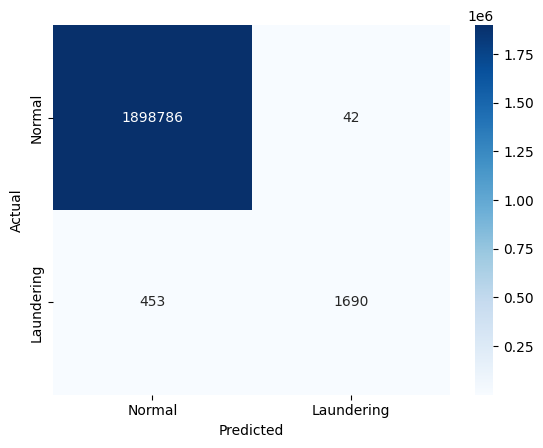

In [14]:
# --- Подбор порога и финальный экзамен ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm.notebook import tqdm

MODEL_SAVE_PATH = "/kaggle/working/best_model.pth"

print("Загрузка лучшей сохраненной модели...")

best_model = EdgeClassifierSAGE(
    in_channels_node=train_data.x.size(1),
    in_channels_edge=train_data.edge_attr.size(1),
    hidden_channels=256,
).to(device)

best_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
print("Модель успешно загружена.")

# 1. Подбор оптимального порога на валидационной выборке
# ---------------------------------------------------------
print("\n1. Подбор оптимального порога на валидационной выборке...")
# Получаем предсказания (вероятности) для валидационной выборки
val_true, val_probs, _, _, _ = evaluate(val_loader, best_model)

best_f1 = 0
best_threshold = 0
# Пробуем 100 разных порогов от 0.01 до 0.99
thresholds = np.linspace(0.01, 0.99, 100)

for threshold in tqdm(thresholds, desc="Подбор порога"):
    preds = (val_probs[:, 1] > threshold).astype(int)
    f1 = f1_score(val_true, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n---> ЛУЧШИЙ РЕЗУЛЬТАТ НА ВАЛИДАЦИИ <---")
print(f"Оптимальный порог: {best_threshold:.4f}")
print(f"Максимальный F1-score: {best_f1:.4f}")


# 2. Финальная оценка на тестовой выборке с лучшим порогом
# ---------------------------------------------------------
print("\n2. Финальная оценка на тестовой выборке (экзамен)...")
test_true, test_probs, test_roc_auc, test_pr_auc, _ = evaluate(test_loader, best_model)

# Применяем найденный оптимальный порог к тестовым данным
test_preds = (test_probs[:, 1] > best_threshold).astype(int)

print("\n\n--- ИТОГОВЫЙ ОТЧЕТ ПО ТЕСТОВОЙ ВЫБОРКЕ ---")
print(f"ROC AUC: {test_roc_auc:.4f}")
print(f"PR AUC: {test_pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(test_true, test_preds, target_names=['Normal', 'Laundering']))

print("\nConfusion Matrix:")
cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Laundering'], yticklabels=['Normal', 'Laundering'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# --- Финальная упаковка ---
import pickle
import os
import shutil
import pandas as pd
import torch

print("--- Финальная упаковка проекта ShAMLock (Kaggle) ---")

# ===================================================================
# ЧАСТЬ 1: УПАКОВКА АРТЕФАКТОВ
# ===================================================================
print("\n--- Часть 1: Упаковка артефактов ---")
FINAL_MODEL_PATH = "/kaggle/working/shamlock_model/"
BEST_MODEL_SOURCE_PATH = "/kaggle/working/best_model.pth"
INDICES_SOURCE_PATH = "/kaggle/working/indices/"
if not os.path.exists(FINAL_MODEL_PATH): os.makedirs(FINAL_MODEL_PATH)
if os.path.exists(BEST_MODEL_SOURCE_PATH):
    shutil.copy(BEST_MODEL_SOURCE_PATH, os.path.join(FINAL_MODEL_PATH, "shamlock_best_model.pth"))
if os.path.exists(INDICES_SOURCE_PATH):
    shutil.copytree(INDICES_SOURCE_PATH, os.path.join(FINAL_MODEL_PATH, "indices"), dirs_exist_ok=True)
with open(os.path.join(FINAL_MODEL_PATH, 'account_to_id.pkl'), 'wb') as f: pickle.dump(account_to_id, f)
with open(os.path.join(FINAL_MODEL_PATH, 'edge_encoder.pkl'), 'wb') as f: pickle.dump(edge_encoder, f)
with open(os.path.join(FINAL_MODEL_PATH, 'edge_scaler.pkl'), 'wb') as f: pickle.dump(edge_scaler, f)
with open(os.path.join(FINAL_MODEL_PATH, 'node_scaler.pkl'), 'wb') as f: pickle.dump(node_scaler, f)
node_features_scaled_df.to_pickle(os.path.join(FINAL_MODEL_PATH, 'node_features.pkl'))
with open(os.path.join(FINAL_MODEL_PATH, 'best_threshold.pkl'), 'wb') as f: pickle.dump(best_threshold, f)
print("--- Упаковка артефактов завершена. ---")


# ===================================================================
# ЧАСТЬ 2: СОЗДАНИЕ ФАЙЛА С ПРОГНОЗАМИ
# ===================================================================
print("\n--- Часть 2: Создание файла с прогнозами для тестовой выборки ---")

try:
    # 1. Загрузка модели
    print("1/3: Загрузка обученной модели...")
    device = torch.device('cpu')
    model = EdgeClassifierSAGE(in_channels_node=train_data.x.size(1), in_channels_edge=train_data.edge_attr.size(1)).to(device)
    model.load_state_dict(torch.load(BEST_MODEL_SOURCE_PATH, map_location=device))
    model.eval()
    print("...модель успешно загружена.")

    # 2. Получение предсказаний
    print("2/3: Получение предсказаний...")
    with torch.no_grad():
        test_data = test_data.to(device)
        
        out = model(
            x=test_data.x, 
            edge_index=test_data.edge_index, 
            edge_attr=test_data.edge_attr, 
            edge_label_index=test_data.edge_index
        )
        
        probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        
    labels = (probs > best_threshold).astype(int)
    print("...предсказания готовы.")

    # 3. Формирование и сохранение CSV файла
    print("3/3: Формирование и сохранение итогового CSV...")
    results_df = df_test.reset_index(drop=True).copy()
    results_df['predicted_probability'] = probs
    results_df['predicted_label'] = labels
    output_csv_path = os.path.join(FINAL_MODEL_PATH, 'test_predictions.csv')
    results_df.to_csv(output_csv_path, index=False)
    print(f"...файл с прогнозами сохранен: {output_csv_path}")

    print(f"\n✅ Проект ShAMLock полностью упакован. Папка для скачивания: {FINAL_MODEL_PATH}")
    print("   Внутри вы найдете все артефакты и файл 'test_predictions.csv'.")

except NameError as e:
    print(f"\n❌ ОШИБКА: Необходимая переменная не найдена: {e}.")
    print("   Убедитесь, что все предыдущие ячейки (особенно 2, 3, 6 и 7) были выполнены перед запуском этой ячейки.")
except Exception as e:
    print(f"\n❌ Произошла непредвиденная ошибка: {e}")


--- Финальная упаковка проекта ShAMLock (Kaggle) ---

--- Часть 1: Упаковка артефактов ---
--- Упаковка артефактов завершена. ---

--- Часть 2: Создание файла с прогнозами для тестовой выборки ---
1/3: Загрузка обученной модели...
...модель успешно загружена.
2/3: Получение предсказаний...


In [23]:
import shutil
import os

folder_to_archive = '/kaggle/working/shamlock_model'

output_filename = 'shamlock_model_archive'

if os.path.exists(folder_to_archive):
    shutil.make_archive(output_filename, 'zip', folder_to_archive)
    print(f"✅ Архив '{output_filename}.zip' успешно создан!")
    print("Теперь найдите его в боковой панели 'Output' и скачайте.")
else:
    print(f"❌ Папка '{folder_to_archive}' не найдена. Убедитесь, что ячейка 8 отработала без ошибок.")

✅ Архив 'shamlock_model_archive.zip' успешно создан!
Теперь найдите его в боковой панели 'Output' и скачайте.
